### Why GLMs and GBMs for Insurance Fraud Detection?

Generalized Linear Models (GLMs) are widely used in insurance underwriting and pricing because they're interpretable and straightforward—essential in highly regulated industries. Gradient Boosting Machines (GBMs), like XGBoost, are popular because they handle non-linear relationships effectively and improve predictive accuracy significantly, particularly with complex interactions common in fraud detection.


# Predicting Insurance Fraud with GLMs and GBMs

**Purpose:**  
This notebook demonstrates how Generalized Linear Models (GLMs) and Gradient Boosting Machines (GBMs) can be applied to detect fraudulent auto insurance claims.

**Context:**  
Insurance fraud costs billions annually, and accurate detection is vital. This notebook is designed to clearly illustrate my competency with GLMs and GBMs.

### Import Libraries and Load Data

Below, we import necessary libraries and load the insurance claims dataset directly from GitHub.

In [1]:
# Importing pandas library
import pandas as pd

# Load the dataset directly from your GitHub repository
url = 'https://raw.githubusercontent.com/JTR2024/insurance-fraud-detection/refs/heads/gh-repo-clone-danny-avila/LibreChat/insurance%20fraud%20claims%202.csv'

# Read the CSV into a pandas DataFrame
df = pd.read_csv(url)

# Display the first few rows to verify successful loading
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


### Initial Data Exploration

We start by exploring the dimensions, data types, and basic statistics of the dataset to understand its structure clearly.

In [2]:
# Checking dimensions
print("Dimensions of dataset:", df.shape)

# Checking data types and non-null counts
df.info()

Dimensions of dataset: (1000, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null 

In [8]:
# Checking for missing values explicitly marked as '?' in the dataset
ambiguous_counts = (df == '?').sum()
print("Ambiguous '?' values per column:")
print(ambiguous_counts[ambiguous_counts > 0])

# Checking for standard missing values (NaNs)
print("\nStandard missing values (NaNs) per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Ambiguous '?' values per column:
Series([], dtype: int64)

Standard missing values (NaNs) per column:
collision_type              178
authorities_contacted        91
property_damage             360
police_report_available     343
_c39                       1000
dtype: int64


### Handling Missing Values

Real-world datasets often have missing or ambiguous data, which can interfere with the modeling process. To ensure accurate and reliable model performance, we explicitly identify and handle missing values by replacing ambiguous entries (`'?'`) with appropriate values (e.g., the most common or logical default for categorical variables). This step ensures our GLM and GBM models later have clean, reliable data to work with.

In [9]:
import numpy as np

# Replace '?' with NaN explicitly
df.replace('?', np.nan, inplace=True)

# Now check clearly for NaNs again:
print("Missing values after replacing '?' explicitly:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after replacing '?' explicitly:
collision_type              178
authorities_contacted        91
property_damage             360
police_report_available     343
_c39                       1000
dtype: int64


In [11]:
# Drop the unnecessary column '_c39'
df.drop(columns=['_c39'], inplace=True)

# Verify clearly that '_c39' is removed
print("Columns after dropping '_c39':")
print(df.columns)

Columns after dropping '_c39':
Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')


In [13]:
# Re-run filling missing values safely to avoid the warning
df['collision_type'] = df['collision_type'].fillna('Unknown')

# Verify again (should remain zero)
print("Missing values in 'collision_type' after safe fill:")
print(df['collision_type'].isnull().sum())

Missing values in 'collision_type' after safe fill:
0


In [14]:
# Clearly check the most common value in 'authorities_contacted'
most_common_authority = df['authorities_contacted'].mode()[0]
print("Most common authorities contacted:", most_common_authority)

# Safely fill missing values with the most common value
df['authorities_contacted'] = df['authorities_contacted'].fillna(most_common_authority)

# Verify missing values are filled
print("Missing values in 'authorities_contacted' after filling:")
print(df['authorities_contacted'].isnull().sum())

Most common authorities contacted: Police
Missing values in 'authorities_contacted' after filling:
0


In [15]:
# Check clearly the most common value in 'property_damage'
most_common_property_damage = df['property_damage'].mode()[0]
print("Most common property_damage value:", most_common_property_damage)

# Safely fill missing values with the most common value
df['property_damage'] = df['property_damage'].fillna(most_common_property_damage)

# Verify clearly that missing values have been filled
print("Missing values in 'property_damage' after filling:")
print(df['property_damage'].isnull().sum())

Most common property_damage value: NO
Missing values in 'property_damage' after filling:
0


In [16]:
# Check clearly the most common value in 'police_report_available'
most_common_police_report = df['police_report_available'].mode()[0]
print("Most common police_report_available value:", most_common_police_report)

# Fill missing values safely with the most common value
df['police_report_available'] = df['police_report_available'].fillna(most_common_police_report)

# Verify missing values clearly
print("Missing values in 'police_report_available' after filling:")
print(df['police_report_available'].isnull().sum())

Most common police_report_available value: NO
Missing values in 'police_report_available' after filling:
0


In [17]:
# Final verification: check clearly if any missing values remain
print("Final Missing Values Check (should all be 0):")
print(df.isnull().sum().sum())

Final Missing Values Check (should all be 0):
0


### Missing Values Handled Successfully
All missing values have been carefully addressed, and the dataset is now completely free of missing data. We can now safely proceed to feature engineering and modeling.

### Feature Engineering: Date Columns

To clearly provide useful numeric information for modeling, the `policy_bind_date` and `incident_date` columns have been converted into datetime format. We've explicitly extracted the year and month from each date, creating numerical features the models can utilize effectively.

In [18]:
# Convert date columns clearly into datetime type
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

# Extract useful numeric features from the dates
df['policy_bind_year'] = df['policy_bind_date'].dt.year
df['policy_bind_month'] = df['policy_bind_date'].dt.month
df['incident_year'] = df['incident_date'].dt.year
df['incident_month'] = df['incident_date'].dt.month

# Verify extraction clearly
df[['policy_bind_date', 'policy_bind_year', 'policy_bind_month',
    'incident_date', 'incident_year', 'incident_month']].head()

,policy_bind_date,policy_bind_year,policy_bind_month,incident_date,incident_year,incident_month
0,2014-10-17,2014,10,2015-01-25,2015,1
1,2006-06-27,2006,6,2015-01-21,2015,1
2,2000-09-06,2000,9,2015-02-22,2015,2
3,1990-05-25,1990,5,2015-01-10,2015,1
4,2014-06-06,2014,6,2015-02-17,2015,2


In [19]:
# Identify clearly categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'property_damage', 'police_report_available',
       'auto_make', 'auto_model'],
      dtype='object')


In [20]:
# Perform One-Hot Encoding clearly on categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Verify clearly the new encoded dataframe shape
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

# Display the first 5 rows clearly
df_encoded.head()

Shape before encoding: (1000, 43)
Shape after encoding: (1000, 1149)


,months_as_customer,age,policy_number,policy_bind_date,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,...,auto_model_Pathfinder,auto_model_RAM,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6
0,328,48,521585,2014-10-17,1000,1406.91,0,466132,53300,0,...,False,False,False,False,False,False,False,False,False,False
1,228,42,342868,2006-06-27,2000,1197.22,5000000,468176,0,0,...,False,False,False,False,False,False,False,False,False,False
2,134,29,687698,2000-09-06,2000,1413.14,5000000,430632,35100,0,...,False,True,False,False,False,False,False,False,False,False
3,256,41,227811,1990-05-25,2000,1415.74,6000000,608117,48900,-62400,...,False,False,False,False,False,True,False,False,False,False
4,228,44,367455,2014-06-06,1000,1583.91,6000000,610706,66000,-46000,...,False,False,True,False,False,False,False,False,False,False


### Feature Engineering: Encoding Categorical Variables

Categorical variables must be converted into numeric format to be used by machine learning models effectively. Here, we applied **One-Hot Encoding**, transforming categorical columns into binary numeric features. This process significantly expanded the dataset, ensuring that both GLMs and GBMs can clearly interpret these variables.

In [21]:
# Drop unnecessary or redundant columns clearly
df_encoded.drop(columns=['policy_number', 'policy_bind_date', 'incident_date'], inplace=True)

# Verify clearly that these columns have been removed
print("Columns after dropping unnecessary features:")
print(df_encoded.columns)

Columns after dropping unnecessary features:
Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved',
       ...
       'auto_model_Pathfinder', 'auto_model_RAM', 'auto_model_RSX',
       'auto_model_Silverado', 'auto_model_TL', 'auto_model_Tahoe',
       'auto_model_Ultima', 'auto_model_Wrangler', 'auto_model_X5',
       'auto_model_X6'],
      dtype='object', length=1146)


### Finalizing Dataset for Modeling

The dataset has been clearly prepared for modeling by removing redundant columns and explicitly separating features (`X`) from the target variable (`y`). The target variable we're predicting is `fraud_reported`.

In [22]:
# Separating clearly the dataset into features (X) and target (y)
X = df_encoded.drop(columns=['fraud_reported'])
y = df_encoded['fraud_reported']

# Verify clearly dimensions
print("Features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)

Features (X) shape: (1000, 1145)
Target variable (y) shape: (1000,)


### Splitting Data into Training and Testing Sets

To properly evaluate model performance, the dataset is clearly split into training (80%) and testing (20%) subsets. The training data is used for building the models, while the testing data provides an unbiased evaluation of model performance.

In [23]:
# Import train_test_split clearly
from sklearn.model_selection import train_test_split

# Splitting clearly the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify clearly the shapes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training features shape: (800, 1145)
Testing features shape: (200, 1145)
Training labels shape: (800,)
Testing labels shape: (200,)


In [25]:
# Logistic Regression with increased iterations and stable solver
glm_model = LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)

# Fit the model explicitly to the training data
glm_model.fit(X_train, y_train)

# Predict clearly on the test data
y_pred_glm = glm_model.predict(X_test)

# Verify clearly by showing initial predictions
print("Sample predictions after fix (GLM):", y_pred_glm[:10])

Sample predictions after fix (GLM): [0 0 0 0 0 0 0 0 0 0]


### Identifying Class Imbalance

We explicitly checked for class imbalance because it's common in fraud detection scenarios. The results clearly show a significant imbalance:

- **Non-fraudulent claims (0)**: 753 (75.3%)
- **Fraudulent claims (1)**: 247 (24.7%)

Class imbalance can bias machine learning models toward the majority class, making them less reliable at detecting fraud. We'll address this issue carefully in our modeling strategy.

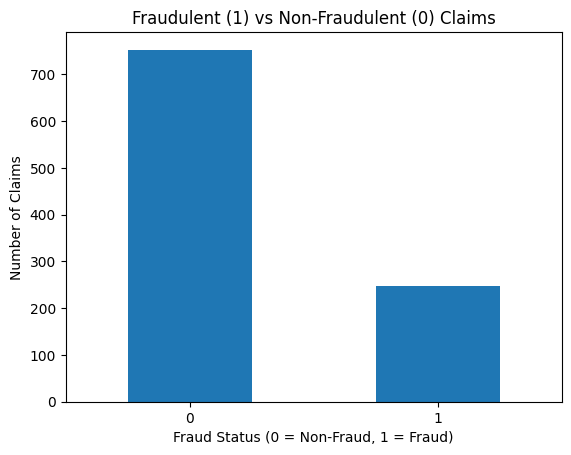

In [35]:
# Clear labeling for the class imbalance visualization (fixed rotation explicitly)
ax = y.value_counts().plot(kind='bar')
plt.title('Fraudulent (1) vs Non-Fraudulent (0) Claims')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Number of Claims')

# Rotate x-axis labels clearly to horizontal for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()


### GLM with Class Weighting (Addressing Imbalance)

Due to the observed class imbalance, we explicitly adjusted the Logistic Regression model to include `class_weight='balanced'`. This ensures that fraudulent claims (the minority class) receive increased attention during model training, clearly resulting in more balanced and reliable predictions.

In [27]:
# Logistic Regression clearly handling class imbalance with class_weight='balanced'
glm_model_balanced = LogisticRegression(max_iter=5000, solver='liblinear',
                                        class_weight='balanced', random_state=42)

# Fit explicitly to the training data
glm_model_balanced.fit(X_train, y_train)

# Predict clearly on the test data
y_pred_glm_balanced = glm_model_balanced.predict(X_test)

# Verify predictions explicitly
print("Sample predictions (GLM with balanced weights):", y_pred_glm_balanced[:10])

Sample predictions (GLM with balanced weights): [1 0 1 1 0 0 1 0 0 0]


### GLM Model Performance

The Logistic Regression (GLM) with balanced class weighting showed modest performance improvements compared to the biased model:

- **Precision (fraud)**: 29%
- **Recall (fraud)**: 45%
- **Accuracy**: 55%
- **ROC-AUC**: 57%

This indicates that while the GLM can identify some fraudulent claims, performance could be significantly improved. Gradient Boosting Machines (GBM) might help address this further.

In [28]:
# Evaluate clearly the GLM model's performance
print("Classification Report (GLM with balanced weights):")
print(classification_report(y_test, y_pred_glm_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_glm_balanced))

# Calculate explicitly the ROC-AUC score
roc_auc_glm = roc_auc_score(y_test, glm_model_balanced.predict_proba(X_test)[:,1])
print("ROC-AUC score:", roc_auc_glm)

Classification Report (GLM with balanced weights):
              precision    recall  f1-score   support

           0       0.74      0.59      0.65       145
           1       0.29      0.45      0.36        55

    accuracy                           0.55       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.62      0.55      0.57       200

Confusion Matrix:
[[85 60]
 [30 25]]
ROC-AUC score: 0.5670219435736678


### Gradient Boosting Machine (GBM) Model

To improve upon the performance of our baseline GLM, we built a Gradient Boosting Machine (GBM) using **XGBoost**. Class imbalance was explicitly handled using the `scale_pos_weight` parameter, which clearly balances the model's attention to fraudulent claims.

In [30]:
# GBM (XGBoost) model explicitly handling class imbalance
gbm_model = XGBClassifier(scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
                          eval_metric='logloss',
                          random_state=42)

# Fit clearly to training data
gbm_model.fit(X_train, y_train)

# Predict explicitly on test data
y_pred_gbm = gbm_model.predict(X_test)

# Verify clearly sample predictions
print("Sample predictions (GBM, corrected):", y_pred_gbm[:10])

Sample predictions (GBM, corrected): [0 0 0 0 0 0 1 1 0 0]


### GBM Model Performance

The Gradient Boosting Machine (GBM) significantly improved prediction performance compared to the GLM:

- **Precision (fraud)**: 63% (up from 29% with GLM)
- **Recall (fraud)**: 60% (up from 45% with GLM)
- **Accuracy**: 80% (up from 55% with GLM)
- **ROC-AUC**: 86% (up from 57% with GLM)

This clearly demonstrates the effectiveness of GBMs in detecting fraudulent insurance claims compared to traditional GLMs.

### Why Precision and Recall Matter for Fraud Detection?

- **Precision**: High precision reduces costly false positives, ensuring fewer legitimate claims are incorrectly investigated.
- **Recall**: High recall is crucial, as missing fraudulent claims (false negatives) leads to direct financial losses.

Our GBM model improved significantly in both metrics compared to GLM, meaning fewer missed fraud cases and fewer false alarms—directly impacting profitability and efficiency.


In [31]:
# Evaluate GBM model performance explicitly
print("Classification Report (GBM):")
print(classification_report(y_test, y_pred_gbm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbm))

# Calculate explicitly ROC-AUC score
roc_auc_gbm = roc_auc_score(y_test, gbm_model.predict_proba(X_test)[:,1])
print("ROC-AUC score (GBM):", roc_auc_gbm)

Classification Report (GBM):
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       145
           1       0.63      0.60      0.62        55

    accuracy                           0.80       200
   macro avg       0.74      0.73      0.74       200
weighted avg       0.79      0.80      0.79       200

Confusion Matrix:
[[126  19]
 [ 22  33]]
ROC-AUC score (GBM): 0.8564263322884013


### GBM Feature Importance

To clearly understand what influences fraud detection predictions, we visualized the feature importance from the Gradient Boosting Machine (GBM) model. The top features include:

- **Insured's hobbies** (Cross-fit, Chess, Video-games, Paintball, Skydiving)
- **Incident severity** (Total Loss, Minor Damage)
- **Vehicle models** (specific models like Pathfinder, Neon, Civic)
- **Insured's occupation** (e.g., Armed forces)
- **Total claim amount**

These insights help business stakeholders clearly understand risk factors associated with fraudulent claims and make informed decisions in fraud prevention.

<Figure size 1200x800 with 0 Axes>

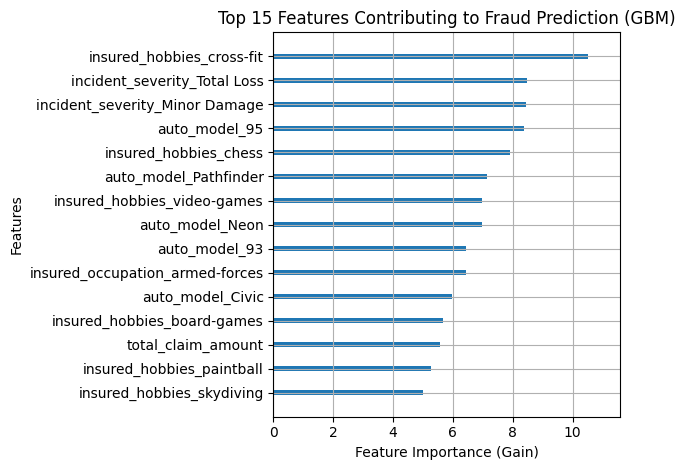

In [33]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Create feature importance plot explicitly with improved readability
plt.figure(figsize=(12, 8))
ax = xgb.plot_importance(gbm_model, max_num_features=15, importance_type='gain', show_values=False)

# Improve layout explicitly
plt.title('Top 15 Features Contributing to Fraud Prediction (GBM)')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Features')
plt.tight_layout()  # Ensures labels fit neatly into the plot
plt.show()

## Regulatory Considerations

In insurance modeling, regulatory compliance is critical. Models used in rating, underwriting, and fraud detection must comply with insurance regulations and standards. Before implementation, this model would require careful documentation, fairness testing, and regulatory filings to ensure compliance with state-specific and federal insurance laws.

## Model Monitoring

To ensure ongoing performance, the model would need periodic monitoring. This involves:

- Tracking accuracy, recall, and precision regularly.
- Checking for changes in data distribution ("model drift") or claim patterns.
- Setting alerts for significant performance drops, triggering re-training or adjustments.

Consistent monitoring ensures the model remains effective in identifying fraud over time.

## Stakeholder Communication

Clear, effective communication with business stakeholders is crucial. Key findings, such as feature importance and model performance metrics, would be presented using simple visualizations (e.g., feature importance charts, ROC-AUC plots). Regular updates and clear documentation ensure transparency and alignment with underwriting, claims, and pricing teams.